<a href="https://colab.research.google.com/github/Madhuanabala/deepak-bhaiya_new/blob/classification-models-rdkit/QD%2Bundersampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original dataset shape: (653, 20), (653,)
Resampled dataset shape: (198, 20), (198,)
Model: Quadratic Discriminant Analysis with Random Undersampling
Accuracy: 0.7
Balanced Accuracy: 0.7843137254901961
ROC AUC: 0.8303321328531412
F1 Score: 0.475
Cohen's Kappa: 0.3258426966292135
Mean Absolute Error: 0.3

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.66      0.79       238
           1       0.32      0.90      0.47        42

    accuracy                           0.70       280
   macro avg       0.65      0.78      0.63       280
weighted avg       0.88      0.70      0.74       280



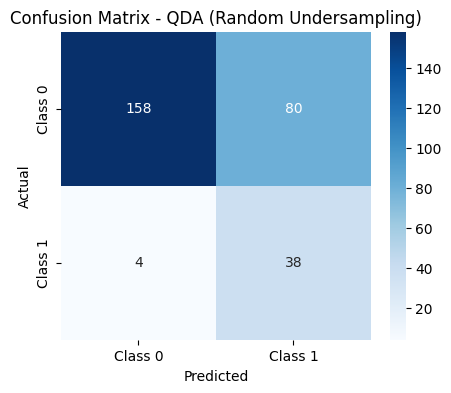

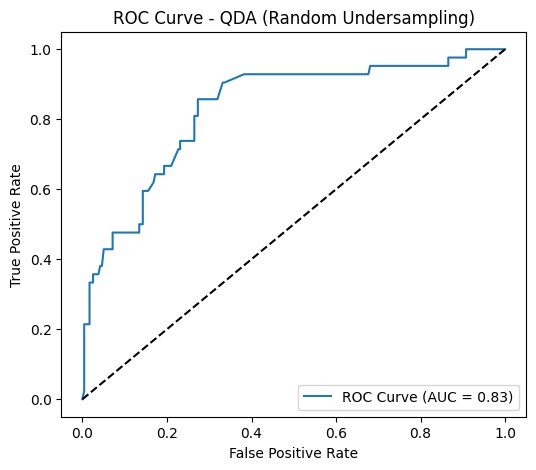

In [1]:
!pip install matplotlib seaborn scikit-learn imbalanced-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, cohen_kappa_score, mean_absolute_error,
    roc_curve
)
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler


df = pd.read_csv("/content/MACCS2_Trainset_top20.csv")


X = df.drop(["BioactivityClass"], axis=1)
y = df["BioactivityClass"]


if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print(f"Original dataset shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled dataset shape: {X_train_res.shape}, {y_train_res.shape}")


model = QuadraticDiscriminantAnalysis()
model.fit(X_train_res, y_train_res)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("Model: Quadratic Discriminant Analysis with Random Undersampling")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("F1 Score:", f1_score(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - QDA (Random Undersampling)')
plt.show()


fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - QDA (Random Undersampling)')
plt.legend(loc='lower right')
plt.show()

In [2]:

metrics = {
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test, y_pred)],
    "ROC AUC": [roc_auc_score(y_test, y_prob)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "Cohen's Kappa": [cohen_kappa_score(y_test, y_pred)],
    "Mean Absolute Error": [mean_absolute_error(y_test, y_pred)],
}

df_metrics = pd.DataFrame(metrics)
df_metrics.to_excel("QDA_RUS_metrics.xlsx", index=False)
print("\nMetrics saved to 'QDA_RUS_metrics.xlsx'")


from collections import Counter
pred_counts = Counter(y_pred)
print("\nPredicted class distribution:", pred_counts)

df_pred_counts = pd.DataFrame.from_dict(pred_counts, orient="index", columns=["Count"])
df_pred_counts.to_excel("QDA_RUS_pred_counts.xlsx")
print("Prediction counts saved to 'QDA_RUS_pred_counts.xlsx'")





Metrics saved to 'QDA_RUS_metrics.xlsx'

Predicted class distribution: Counter({np.int64(0): 162, np.int64(1): 118})
Prediction counts saved to 'QDA_RUS_pred_counts.xlsx'
